# Demonstrate reading of data from Vannan et al.

Paper: [Vannan et al.](https://www.nature.com/articles/s41588-025-02080-x#data-availability)
All data from the paper is accessible [here](https://www.ncbi.nlm.nih.gov/geo/query/acc.cgi?acc=GSE250346).

For the demo we use the data of "TMA5":
- [Xenium data](https://ftp.ncbi.nlm.nih.gov/geo/series/GSE250nnn/GSE250346/suppl/GSE250346%5FIPFTMA5.tar.gz)
- [HE images](https://ftp.ncbi.nlm.nih.gov/geo/series/GSE250nnn/GSE250346/suppl/GSE250346%5FIPFTMA5.svs.tiff.gz)

In [1]:
## The following code ensures that all functions and init files are reloaded before executions.
%load_ext autoreload
%autoreload 2

In [2]:
from pathlib import Path

from insitupy.io import read_xenium

c:\Users\ge37voy\AppData\Local\miniconda3\envs\insitupy\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


After extraction of the data from the `tar.gz` file, data is located in `GSE250346_IPFTMA5/IPFTMA5`. 

In [20]:
data_path = Path(r"E:\vannan\GSE250346_IPFTMA5\IPFTMA5")

In [21]:
xd = read_xenium(data_path)

INFO: Reading Xenium data with InSituPy backend...


Loading cells...
Loading images...


2025-12-22 10:43:19 | [WARNING] <tifffile.TiffFile 'morphology_focus_0000.ome.tif'> OME series cannot read multi-file pyramids


Loading transcripts...


In [22]:
xd

InSituData
Method:		Xenium
Slide ID:	0024909
Sample ID:	CustomPanel
Path:		E:\vannan\GSE250346_IPFTMA5\IPFTMA5

    ➤ images
       'nuclei':   (91812, 54047)
    ➤ cells
       MultiCellData with main layer 'main'
           table
               AnnData object with n_obs × n_vars = 628860 × 343
               obs: 'transcript_counts', 'control_probe_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area'
               var: 'gene_ids', 'feature_types', 'genome'
               obsm: 'spatial'
           boundaries
               BoundariesData object with 2 entries:
                   cells
                   nuclei
    ➤ transcripts
       DataFrame with shape <dask_expr.expr.Scalar: expr=ReadParquetFSSpec(9515f70).size() // 11, dtype=int64> x 11

In [23]:
xd.import_regions(data_path.parent.parent / "IPFTMA5_regions/TMA.geojson", keys="TMA", scale_factor=1)

In [24]:
xd

InSituData
Method:		Xenium
Slide ID:	0024909
Sample ID:	CustomPanel
Path:		E:\vannan\GSE250346_IPFTMA5\IPFTMA5

    ➤ images
       'nuclei':   (91812, 54047)
    ➤ cells
       MultiCellData with main layer 'main'
           table
               AnnData object with n_obs × n_vars = 628860 × 343
               obs: 'transcript_counts', 'control_probe_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area'
               var: 'gene_ids', 'feature_types', 'genome'
               obsm: 'spatial'
           boundaries
               BoundariesData object with 2 entries:
                   cells
                   nuclei
    ➤ regions
       TMA:	6 regions, 6 classes ('A1', 'A2', 'A3', 'B1', 'B2', 'B3')
    ➤ transcripts
       DataFrame with shape <dask_expr.expr.Scalar: expr=ReadParquetFSSpec(9515f70).size() // 11, dtype=int64> x 11

## Visualize whole dataset and add TMA regions

Since all TMA cores are within one dataset, one has to now annotate the individual TMA cores as `regions`. For this, go to the "Add geometries" widget on the right hand side of the napari viewer, select "Type=Regions", add a value for "Key" (e.g. "TMA") and a value for "Class" (e.g. "A1"). Add the regions layer by clicking "Add". Then annotate the region of the first TMA core using the drawing tools provided on the top left. Repeat this procedure for all TMA cores. Importantly, for each TMA core a new shapes layer has to be added by providing a new "Class" (e.g. "A2", "A3", "B1", etc.). Subsequently, the geometries can be synced to the `InSituData` object by clicking "Sync geometries" on the bottom right of the viewer.

In [ ]:
xd.show()

2025-12-22 10:43:29 | [WARNING] QWindowsWindow::setGeometry: Unable to set geometry 1629x983+801+392 (frame: 1651x1039+790+347) on QWidgetWindow/"_QtMainWindowClassWindow" on "\\.\DISPLAY1". Resulting geometry: 2446x1477+804+406 (frame: 2468x1533+793+361) margins: 11, 45, 11, 11 minimum size: 385x500 MINMAXINFO maxSize=0,0 maxpos=0,0 mintrack=600,806 maxtrack=0,0)


INFO: New layer '🌍 A1 (TMA)' created.
INFO: New layer '🌍 A2 (TMA)' created.
INFO: New layer '🌍 A3 (TMA)' created.
INFO: New layer '🌍 B1 (TMA)' created.
INFO: New layer '🌍 B2 (TMA)' created.
INFO: New layer '🌍 B3 (TMA)' created.
---------------------------------------------------------------------------
TypeError                                 Traceback (most recent call last)
File c:\Users\ge37voy\AppData\Local\miniconda3\envs\insitupy\lib\site-packages\napari\_qt\threads\status_checker.py:126, in StatusChecker.calculate_status(self=<napari._qt.threads.status_checker.StatusChecker object>)
    122     return
    124 try:
    125     # Calculate the status change from cursor's movement
--> 126     res = viewer._calc_status_from_cursor()
        viewer = Viewer(camera=Camera(center=(0.0, np.float64(6030.082385789948), np.float64(7345.125508794302)), zoom=np.float64(0.17993749575687482), angles=(0.0, 0.0, 90.0), perspective=0.0, mouse_pan=False, mouse_zoom=True, orientation=(<DepthAxisOr

2025-12-22 13:02:29 | [WARNING] QWindowsWindow::setGeometry: Unable to set geometry 2561x1497+0+35 (frame: 2583x1553-11-10) on QWidgetWindow/"_QtMainWindowClassWindow" on "\\.\DISPLAY1". Resulting geometry: 2560x1494+0+34 (frame: 2582x1550-11-11) margins: 11, 45, 11, 11 minimum size: 744x998 MINMAXINFO maxSize=0,0 maxpos=0,0 mintrack=1138,1553 maxtrack=0,0)
2025-12-22 13:02:29 | [WARNING] QWindowsWindow::setGeometry: Unable to set geometry 2561x1500+0+35 (frame: 2583x1556-11-10) on QWidgetWindow/"_QtMainWindowClassWindow" on "\\.\DISPLAY1". Resulting geometry: 2560x1494+0+34 (frame: 2582x1550-11-11) margins: 11, 45, 11, 11 minimum size: 744x1000 MINMAXINFO maxSize=0,0 maxpos=0,0 mintrack=1138,1556 maxtrack=0,0)
2025-12-22 13:02:29 | [WARNING] QWindowsWindow::setGeometry: Unable to set geometry 2561x1503+0+35 (frame: 2583x1559-11-10) on QWidgetWindow/"_QtMainWindowClassWindow" on "\\.\DISPLAY1". Resulting geometry: 2560x1494+0+34 (frame: 2582x1550-11-11) margins: 11, 45, 11, 11 minimum 

INFO: New layer '🌍 B3 (TMA)' created.


![TMA regions annotated on the nuclei image](../../_static/img/vannan_tma_regions_annotation.png)

![Adding a TMA region in the napari viewer](../../_static/img/vannan_napari_add_tma_region.png)

In [8]:
xd

InSituData
Method:		Xenium
Slide ID:	0024909
Sample ID:	CustomPanel
Path:		E:\vannan\GSE250346_IPFTMA5\IPFTMA5

    ➤ images
       'nuclei':   (91812, 54047)
    ➤ cells
       MultiCellData with main layer 'main'
           table
               AnnData object with n_obs × n_vars = 628860 × 343
               obs: 'transcript_counts', 'control_probe_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area'
               var: 'gene_ids', 'feature_types', 'genome'
               obsm: 'spatial'
           boundaries
               BoundariesData object with 2 entries:
                   cells
                   nuclei
    ➤ regions
       TMA:	6 regions, 6 classes ('A1', 'A2', 'A3', 'B1', 'B2', 'B3')
    ➤ transcripts
       DataFrame with shape <dask_expr.expr.Scalar: expr=ReadParquetFSSpec(f3737d8).size() // 11, dtype=int64> x 11

In [9]:
xd.regions["TMA"]

,objectType,origin,layer_type,geometry,name,color
id,,,,,,
71e1d78f-c358-4c66-8855-509f7ea6d94b,region,file,Shapes,"POLYGON ((1425.59082 2457.01099, 1221.47949 30...",A1,"[255, 170, 0]"
63ebcb72-e979-47dd-a700-f5c667c6162e,region,file,Shapes,"POLYGON ((5059.10596 1476.88135, 4935.9292 189...",A2,"[255, 170, 0]"
7b5012b3-7c4a-4a05-8c3c-21e24b1142b7,region,file,Shapes,"POLYGON ((8773.82812 800.05548, 8568.34375 159...",A3,"[255, 170, 0]"
d85109c0-d78c-4872-bb35-d7c4a3d62c66,region,file,Shapes,"POLYGON ((1036.69885 3338.63794, 907.56073 478...",B1,"[255, 170, 0]"
a38e6db1-fd7d-4a5f-a2d1-fb3228953eb0,region,file,Shapes,"POLYGON ((4927.44873 5142.26123, 4849.4292 551...",B2,"[255, 170, 0]"
d3763572-b2fd-4123-a989-702107e09d4a,region,file,Shapes,"POLYGON ((8665.07812 4103.98389, 8458.31738 51...",B3,"[255, 170, 0]"


Saving the transcript data can take very long. To speed up the process for this tutorial, we remove the transcripts in the following step.

In [10]:
del xd.transcripts

In [4]:
from insitupy import InSituExperiment

In [14]:
exp = InSituExperiment.from_regions(xd, region_key="TMA")

In [15]:
exp

InSituExperiment (insitupy mode) with 6 samples:
           uid  CITAR slide_id    sample_id region_key region_name
0     1097134d  ++--+  0024909  CustomPanel        TMA          A1
1     5a16ef86  ++--+  0024909  CustomPanel        TMA          A2
2     169485b8  ++--+  0024909  CustomPanel        TMA          A3
3     a7059e74  ++--+  0024909  CustomPanel        TMA          B1
4     8e9d8c12  ++--+  0024909  CustomPanel        TMA          B2
5     e1d7f9bc  ++--+  0024909  CustomPanel        TMA          B3

In [5]:
data_out = data_path.parent.parent / "IPFTMA5_insitupy"

In [ ]:

exp.saveas(data_out)

In [6]:
exp = InSituExperiment.read(data_out)
exp.load_all()

100%|██████████| 6/6 [00:01<00:00,  5.80it/s]


In [7]:
exp

InSituExperiment (insitupy mode) with 6 samples:
           uid  CITAR  slide_id    sample_id region_key region_name
0     1097134d  ++--+     24909  CustomPanel        TMA          A1
1     5a16ef86  ++--+     24909  CustomPanel        TMA          A2
2     169485b8  ++--+     24909  CustomPanel        TMA          A3
3     a7059e74  ++--+     24909  CustomPanel        TMA          B1
4     8e9d8c12  ++--+     24909  CustomPanel        TMA          B2
5     e1d7f9bc  ++--+     24909  CustomPanel        TMA          B3

## Add metadata

Unfortunately, we were not able to find the TMA layout with metadata information for TMA5 from the publication. Therefore, we demonstrate addition of the metadata with mock metadata.

### Option 1: Column by column

In [10]:
exp.add_metadata_column(
    column_name="status",
    values=["Control", "Disease", "Disease", "Control", "Control", "Disease"]
)

### Option 2: Using metadata CSV file

In such a case it is important to specify the `by` argument to correctly pair incoming and existing metadata.

In [15]:
exp.append_metadata(
    new_metadata=r"C:\Users\ge37voy\Github\InSituPy\docs\source\demo_data\demo_experiment\vannan_metadata_mock.csv",
    by="region_name"
)

In [16]:
exp

InSituExperiment (insitupy mode) with 6 samples:
           uid  CITAR  slide_id    sample_id region_key region_name   status clinical_diagnosis       ethnicity tobacco
0     1097134d  ++--+     24909  CustomPanel        TMA          A1  Control         control           european       y
1     5a16ef86  ++--+     24909  CustomPanel        TMA          A2  Disease             IPF           european       y
2     169485b8  ++--+     24909  CustomPanel        TMA          A3  Disease             ILD           european       n
3     a7059e74  ++--+     24909  CustomPanel        TMA          B1  Control             IPF     african ame...       n
4     8e9d8c12  ++--+     24909  CustomPanel        TMA          B2  Control         control           hispanic       y
5     e1d7f9bc  ++--+     24909  CustomPanel        TMA          B3  Disease            NSIP           european       y

## Visualization

In [18]:
from insitupy.plotting import overview, spatial

### Metadata overview

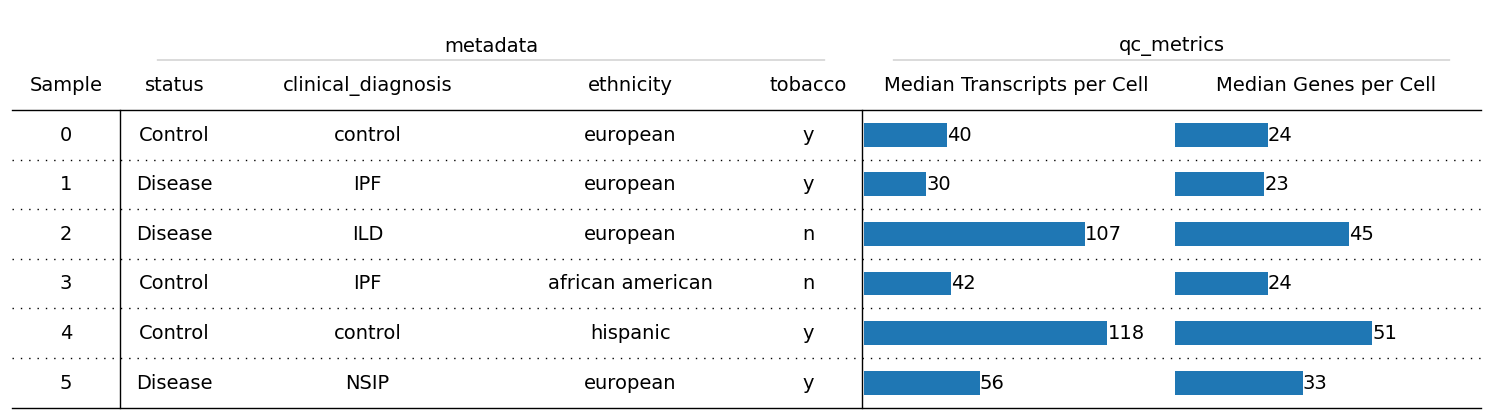

In [19]:
overview(exp, columns_to_plot=["status", "clinical_diagnosis", "ethnicity", "tobacco"])

### Visualize individual datasets in napari viewer

In [26]:
exp.show(0)

2025-12-22 13:21:17 | [WARNING] QWindowsWindow::setGeometry: Unable to set geometry 1629x983+801+392 (frame: 1651x1039+790+347) on QWidgetWindow/"_QtMainWindowClassWindow" on "\\.\DISPLAY1". Resulting geometry: 2446x1477+804+406 (frame: 2468x1533+793+361) margins: 11, 45, 11, 11 minimum size: 385x500 MINMAXINFO maxSize=0,0 maxpos=0,0 mintrack=600,806 maxtrack=0,0)


## Preprocessing

For more information on data preprocessing see [this tutorial](../01_demo_analysis/02_InSituPy_demo_analyze.ipynb).

For iterating through all datasets of an `InSituExperiment` object, one can use `.iterdata()`. For more information on the general funcationalities of the `InSituExperiment` see [this notebook](../02_multisample_analysis/InSituPy_InSituExperiment.ipynb).

In [29]:
from insitupy.plotting import plot_qc_metrics
from insitupy.preprocessing import calculate_qc_metrics

### Calculate QC metrics

In [28]:
for meta, data in exp.iterdata():
    calculate_qc_metrics(data, percent_top=None, log1p=False)

A1


C:\Users\ge37voy\Github\InSituPy\insitupy\plotting\qc.py:96: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


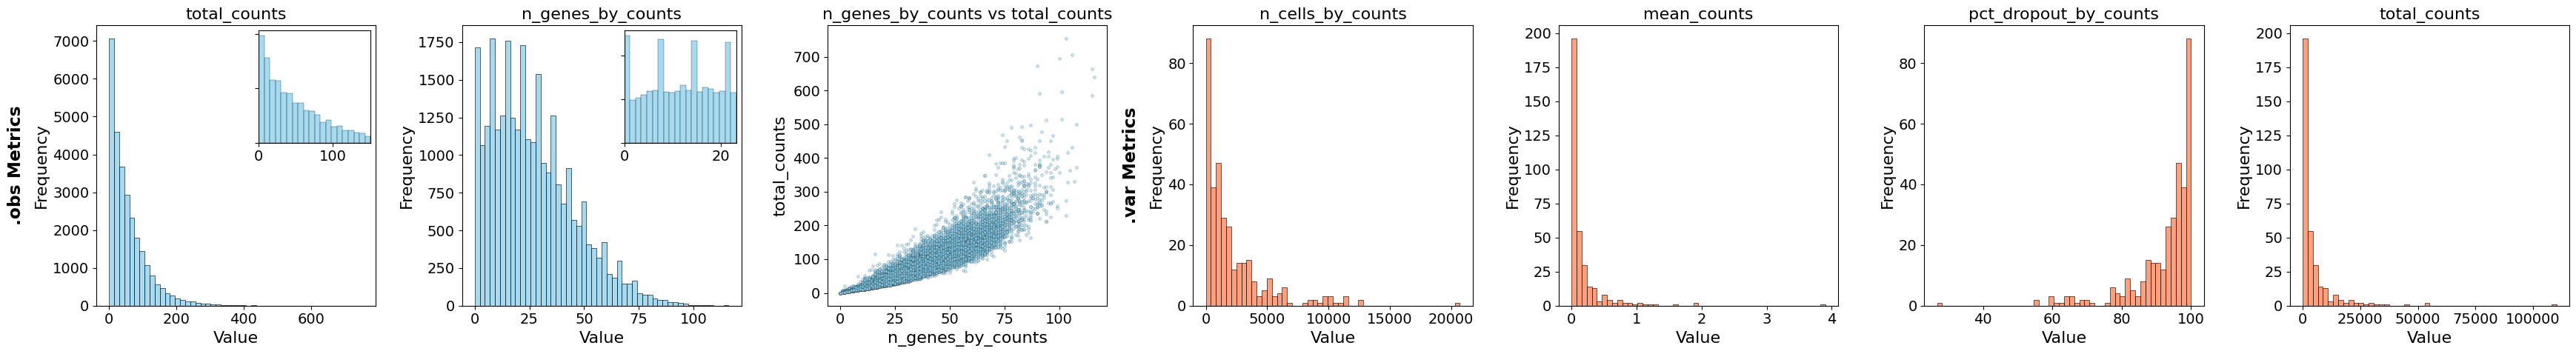

A2


C:\Users\ge37voy\Github\InSituPy\insitupy\plotting\qc.py:96: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


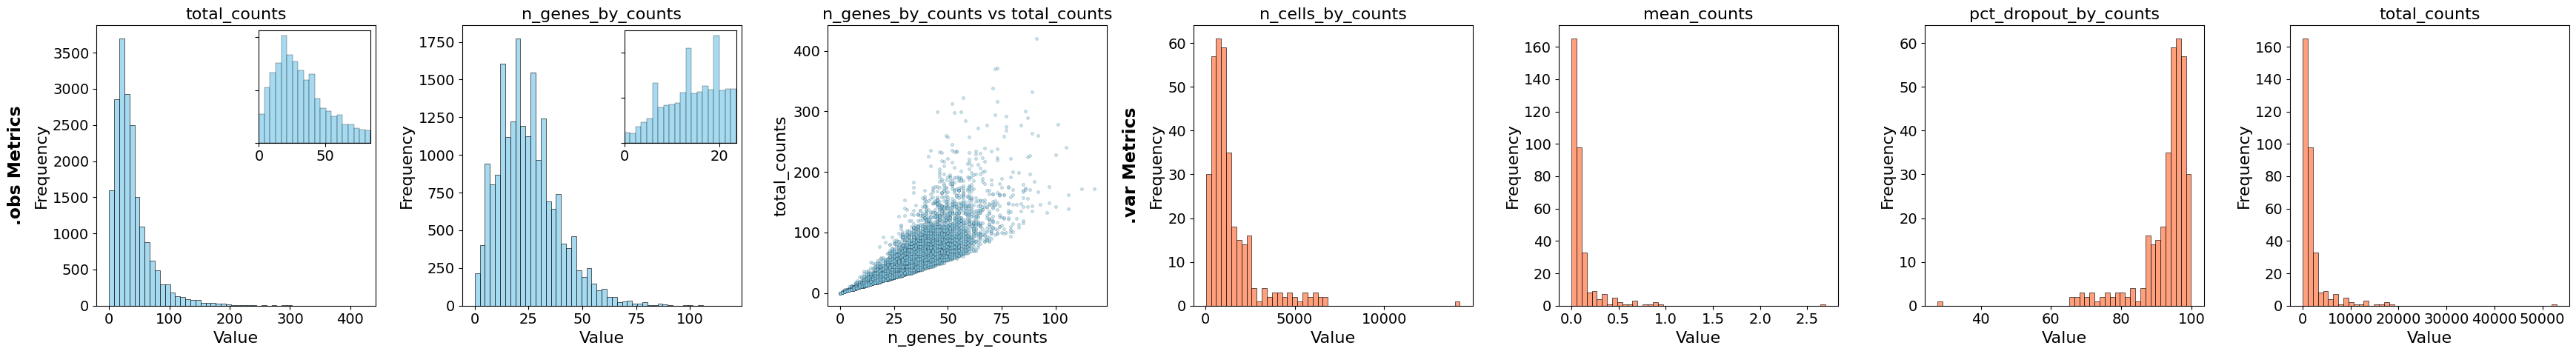

A3


C:\Users\ge37voy\Github\InSituPy\insitupy\plotting\qc.py:96: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


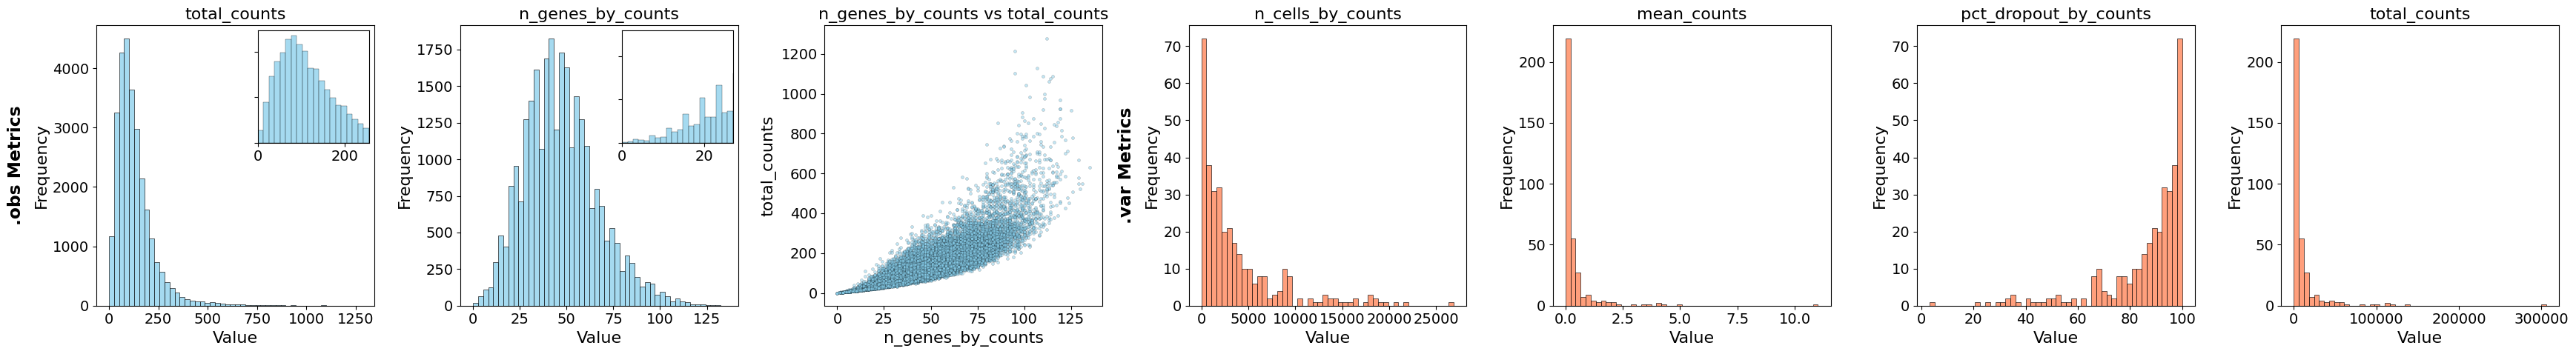

B1


C:\Users\ge37voy\Github\InSituPy\insitupy\plotting\qc.py:96: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


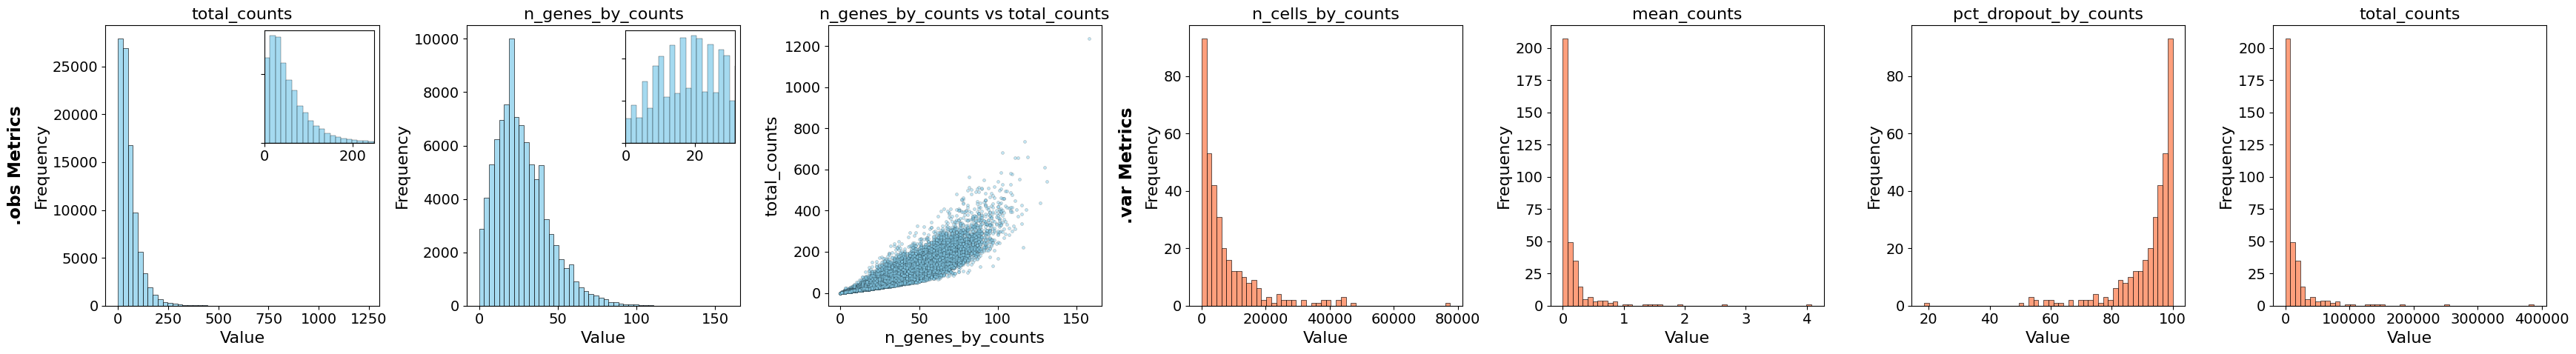

B2


C:\Users\ge37voy\Github\InSituPy\insitupy\plotting\qc.py:96: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


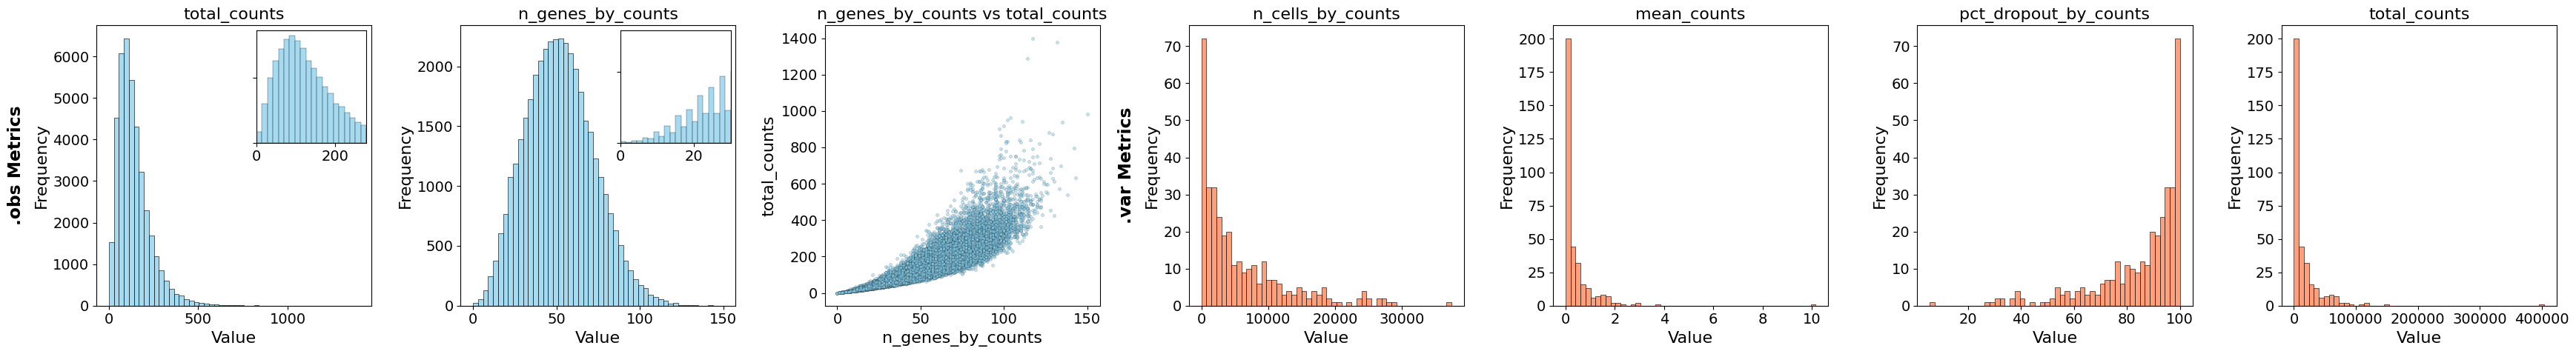

B3


C:\Users\ge37voy\Github\InSituPy\insitupy\plotting\qc.py:96: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


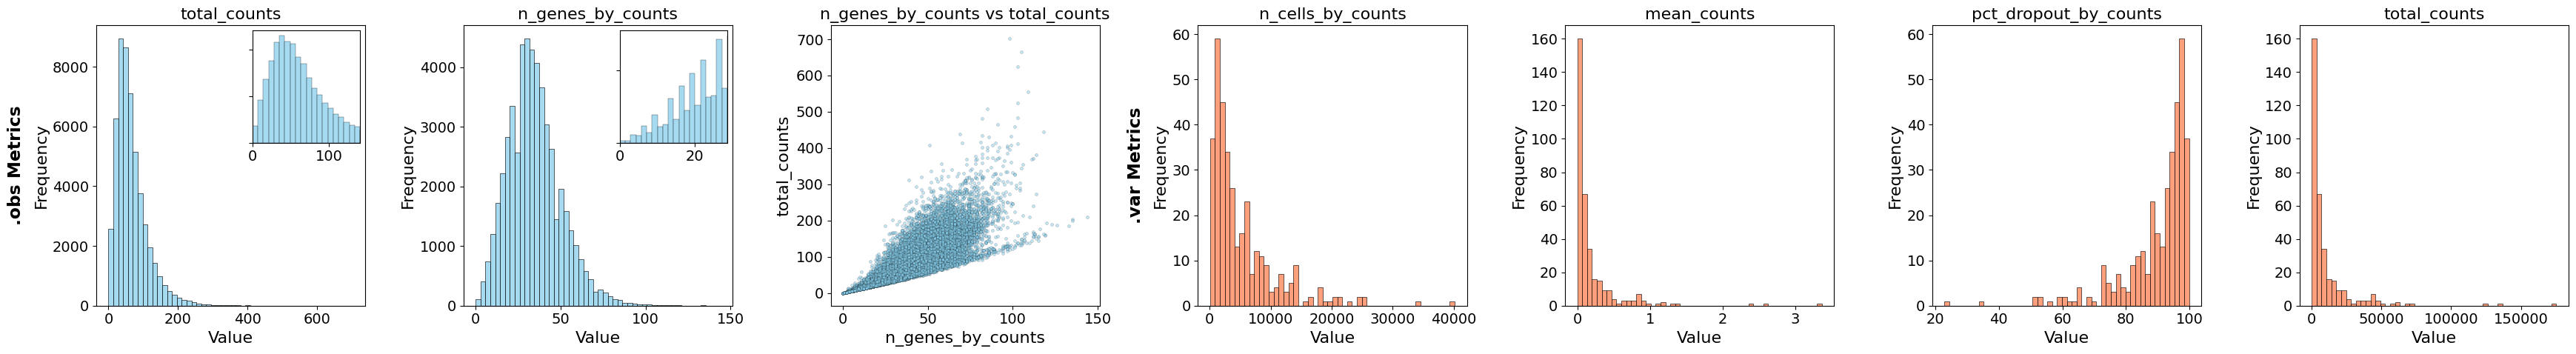

In [31]:
for meta, data in exp.iterdata():
    print(meta["region_name"])
    plot_qc_metrics(data, show_inset=True)

### Normalization and transformation

In [35]:
from insitupy.preprocessing import normalize_and_transform

In [36]:
for meta, data in exp.iterdata():
    normalize_and_transform(
        data,
        transformation_method="log1p",
        target_sum=250,
        scale=False,
        verbose=False
        )

c:\Users\ge37voy\AppData\Local\miniconda3\envs\insitupy\lib\site-packages\legacy_api_wrap\__init__.py:88: UserWarning: Some cells have zero counts
  return fn(*args_all, **kw)


### Dimensionality reduction

In [37]:
from insitupy.preprocessing import cluster_cells, reduce_dimensions

In [38]:
for meta, data in exp.iterdata():
    print(meta["region_name"])
    reduce_dimensions(
        data,
        n_neighbors=15,
        n_pcs=None
        )

A1
Calculate PCA...
Calculate neighbors...
Calculate umap...
A2
Calculate PCA...
Calculate neighbors...
Calculate umap...
A3
Calculate PCA...
Calculate neighbors...
Calculate umap...
B1
Calculate PCA...
Calculate neighbors...
Calculate umap...
B2
Calculate PCA...
Calculate neighbors...
Calculate umap...
B3
Calculate PCA...
Calculate neighbors...
Calculate umap...


### Cluster cells

In [40]:
for meta, data in exp.iterdata():
    print(meta["region_name"])
    cluster_cells(
        data,
        method="leiden"
        )

A1


C:\Users\ge37voy\Github\InSituPy\insitupy\preprocessing\anndata.py:133: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata)


A2
A3
B1
B2
B3


## Save results

In [41]:
exp.save()

100%|██████████| 6/6 [01:11<00:00, 11.99s/it]


In [42]:
exp

InSituExperiment (insitupy mode) with 6 samples:
           uid  CITAR  slide_id    sample_id region_key region_name   status clinical_diagnosis       ethnicity tobacco
0     1097134d  ++--+     24909  CustomPanel        TMA          A1  Control         control           european       y
1     5a16ef86  ++--+     24909  CustomPanel        TMA          A2  Disease             IPF           european       y
2     169485b8  ++--+     24909  CustomPanel        TMA          A3  Disease             ILD           european       n
3     a7059e74  ++--+     24909  CustomPanel        TMA          B1  Control             IPF     african ame...       n
4     8e9d8c12  ++--+     24909  CustomPanel        TMA          B2  Control         control           hispanic       y
5     e1d7f9bc  ++--+     24909  CustomPanel        TMA          B3  Disease            NSIP           european       y

Reload data

In [59]:
exp = InSituExperiment.read(data_out)
exp.load_all()

100%|██████████| 6/6 [00:03<00:00,  1.58it/s]


## Inspect results

### Interactive visualization

In [44]:
exp.show(2)

E.g. we can plot the clusters:
![Cells colored by leiden cluster in the napari viewer](../../_static/img/vannan_napari_leiden_clusters.png)

### Static plotting

Synchronized colors for key 'leiden' and palette 'tab20_mod'.


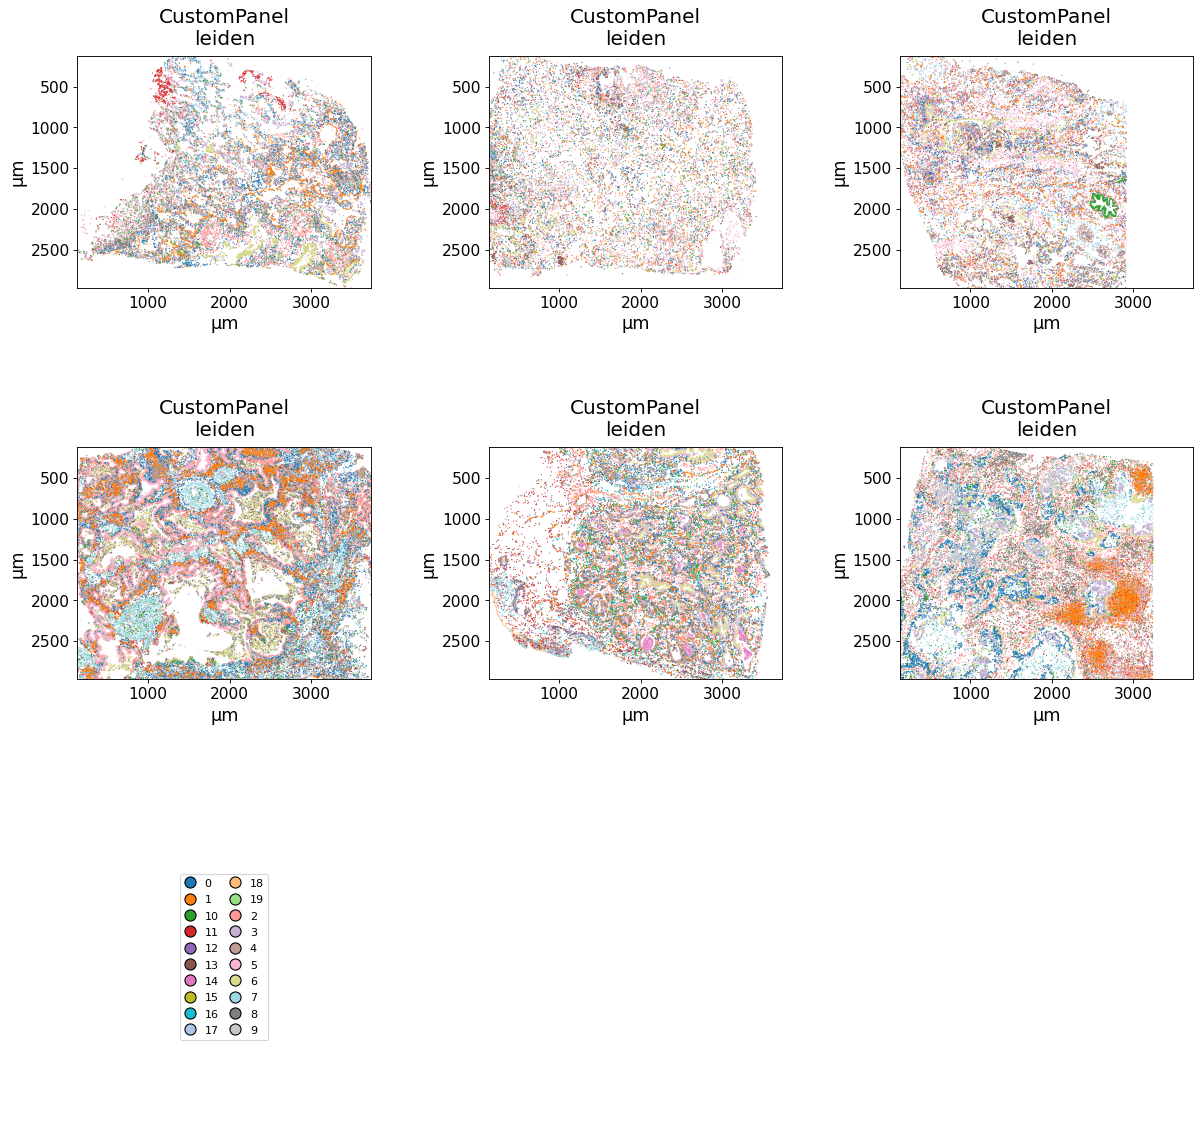

In [60]:
spatial(data=exp, keys="leiden", max_cols=3, savepath="figures/spatial_leiden.pdf")

## Register HE images

To extract the individual HE images from the whole slide image, follow either [this tutorial](./InSituPy_extract_individual_images.ipynb) to do it within InSituPy or use QuPath and export the individual images using [this script](https://github.com/SpatialPathology/InSituPy-QuPath/blob/main/scripts/export_images.groovy).

The image paths we can then add to the `InSituExperiment` metadata as follows:

In [61]:
exp.add_metadata_column(
    column_name="HE_path",
    values=[
        r"E:\vannan\IPFTMA5_HE\image_export\A1.ome.tif",
        r"E:\vannan\IPFTMA5_HE\image_export\A2.ome.tif",
        r"E:\vannan\IPFTMA5_HE\image_export\A3.ome.tif",
        r"E:\vannan\IPFTMA5_HE\image_export\B1.ome.tif",
        r"E:\vannan\IPFTMA5_HE\image_export\B2.ome.tif",
        r"E:\vannan\IPFTMA5_HE\image_export\B3.ome.tif"
        ]
    )

In [62]:
exp.metadata

You are accessing a copy of the metadata. Changes to this DataFrame will not affect the internal metadata. Use `add_metadata_column()` or `append_metadata()` to add new information to the metadata.


,uid,slide_id,sample_id,region_key,region_name,status,clinical_diagnosis,ethnicity,tobacco,HE_path
0,1097134d,24909,CustomPanel,TMA,A1,Control,control,european,y,E:\vannan\IPFTMA5_HE\image_export\A1.ome.tif
1,5a16ef86,24909,CustomPanel,TMA,A2,Disease,IPF,european,y,E:\vannan\IPFTMA5_HE\image_export\A2.ome.tif
2,169485b8,24909,CustomPanel,TMA,A3,Disease,ILD,european,n,E:\vannan\IPFTMA5_HE\image_export\A3.ome.tif
3,a7059e74,24909,CustomPanel,TMA,B1,Control,IPF,african american,n,E:\vannan\IPFTMA5_HE\image_export\B1.ome.tif
4,8e9d8c12,24909,CustomPanel,TMA,B2,Control,control,hispanic,y,E:\vannan\IPFTMA5_HE\image_export\B2.ome.tif
5,e1d7f9bc,24909,CustomPanel,TMA,B3,Disease,NSIP,european,y,E:\vannan\IPFTMA5_HE\image_export\B3.ome.tif


Automated image registration on the whole `InSituExperiment` object we can perform by combining the `register_images` function and `.iterdata()`:

In [63]:
from insitupy.tools import register_images

In [64]:
for meta, data in exp.iterdata():
    name = meta["region_name"]
    print(name)
    he_path = meta["HE_path"]

    register_images(
        data=data,
        image_to_be_registered=he_path,
        axes_image="YXS",
        channel_names='HE',
        template_image_name="nuclei",
        axes_template="YX",
        save_registered_images=True,
        output_dir=data_out.parent / f"registered_images/{name}"
    )

A1
	Processing following histo images: HE
		Loading images to be registered...
		Run color deconvolution on image
Load and scale image data containing all channels.
		Load image into memory...
		Load template into memory...
		Rescale image and template to save memory.
			Rescaled from (7343, 5960, 3) to following dimensions: (4439, 3602, 3)
			Rescaled from (14114, 17609) to following dimensions: (3580, 4467)
		Convert scaled images to 8 bit
Load and scale image data containing only the channels required for registration.
		Rescale image and template to save memory.
			Rescaled from (7340, 5960) to following dimensions: (4438, 3603)
			Rescaled from (14114, 17609) to following dimensions: (3580, 4467)
		Convert scaled images to 8 bit
		Extract common features from image and template
		2025-12-22 14:22:37: Get features...
			Adjust contrast with clip method...
			Method: SIFT...
		2025-12-22 14:22:48: Compute matches...
		2025-12-22 14:23:04: Filter matches...
			Sufficient number of go

In [65]:
exp

InSituExperiment (insitupy mode) with 6 samples:
           uid  CITAR  slide_id    sample_id region_key  ...   status clinical_diagnosis       ethnicity tobacco         HE_path
0     1097134d  ++--+     24909  CustomPanel        TMA  ...  Control         control           european       y  E:\vannan\I...
1     5a16ef86  ++--+     24909  CustomPanel        TMA  ...  Disease             IPF           european       y  E:\vannan\I...
2     169485b8  ++--+     24909  CustomPanel        TMA  ...  Disease             ILD           european       n  E:\vannan\I...
3     a7059e74  ++--+     24909  CustomPanel        TMA  ...  Control             IPF     african ame...       n  E:\vannan\I...
4     8e9d8c12  ++--+     24909  CustomPanel        TMA  ...  Control         control           hispanic       y  E:\vannan\I...
5     e1d7f9bc  ++--+     24909  CustomPanel        TMA  ...  Disease            NSIP           european       y  E:\vannan\I...

Remove the metadata column with the HE image paths again:

In [67]:
exp.remove_metadata_columns("HE_path")

Save the `InSituExperiment` again using `saveas` to include also the registered images. Importantly, using `save()` would not store the registered images, since images are not "variable data" in InSituPy.

In [70]:
data_out_he = data_out.parent / "IPFTMA5_HE_insitupy"

In [ ]:
exp.saveas(data_out_he)

100%|██████████| 6/6 [05:34<00:00, 55.77s/it]


In [71]:
exp = InSituExperiment.read(data_out_he)
exp.load_all()

100%|██████████| 6/6 [00:03<00:00,  1.86it/s]


In [72]:
exp

InSituExperiment (insitupy mode) with 6 samples:
           uid  CITAR  slide_id    sample_id region_key region_name   status clinical_diagnosis       ethnicity tobacco
0     1097134d  ++--+     24909  CustomPanel        TMA          A1  Control         control           european       y
1     5a16ef86  ++--+     24909  CustomPanel        TMA          A2  Disease             IPF           european       y
2     169485b8  ++--+     24909  CustomPanel        TMA          A3  Disease             ILD           european       n
3     a7059e74  ++--+     24909  CustomPanel        TMA          B1  Control             IPF     african ame...       n
4     8e9d8c12  ++--+     24909  CustomPanel        TMA          B2  Control         control           hispanic       y
5     e1d7f9bc  ++--+     24909  CustomPanel        TMA          B3  Disease            NSIP           european       y

Key 'leiden' found already in `exp.colors`. To overwrite it, run `sync_colors` with `overwrite=True`.


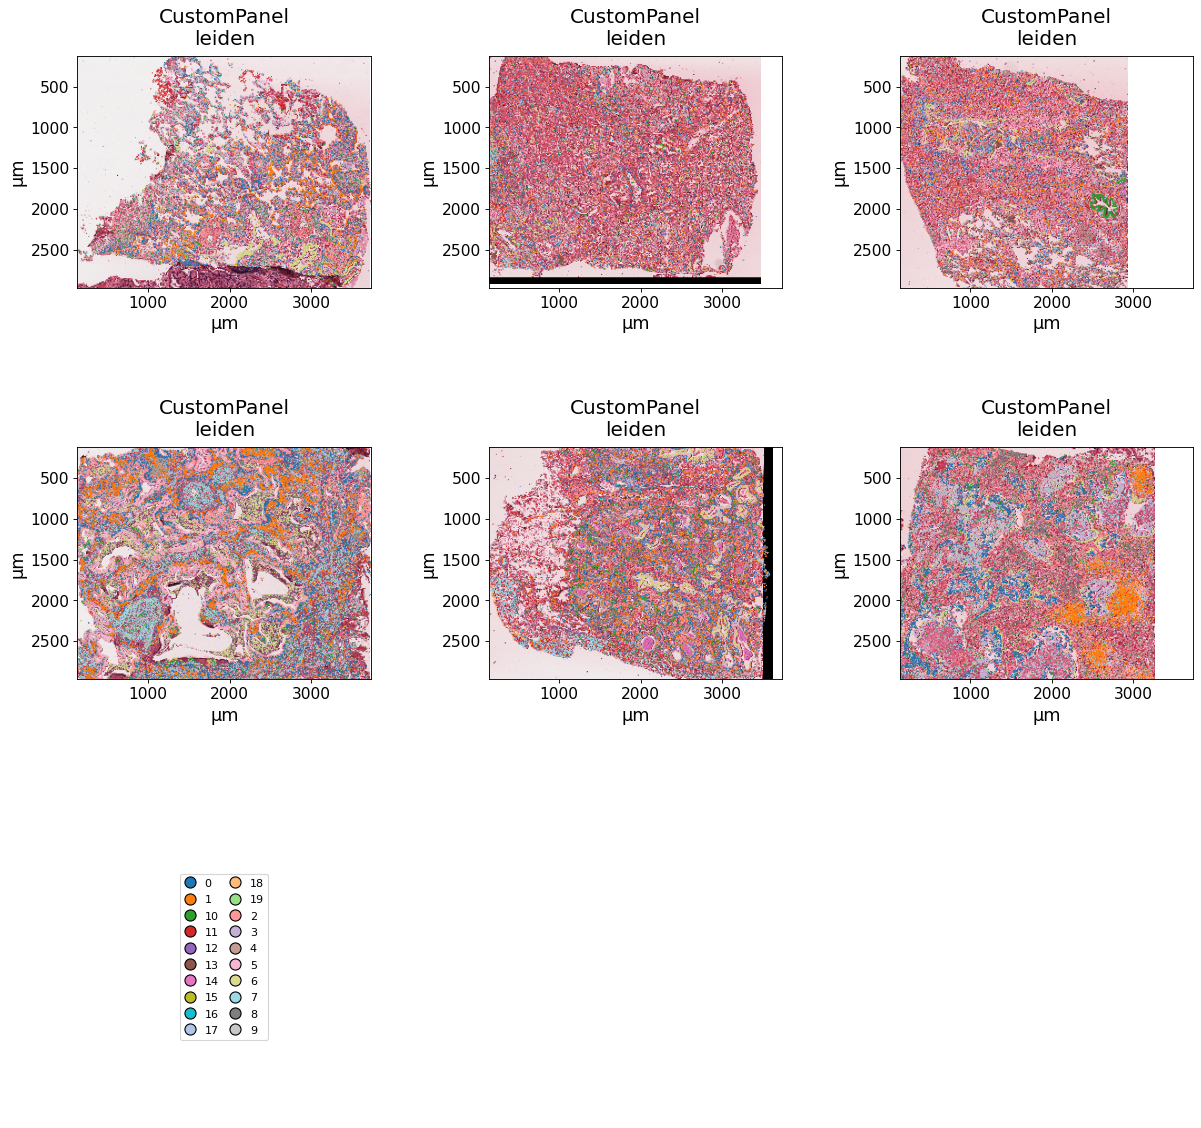

In [73]:
spatial(
    data=exp,
    keys="leiden",
    max_cols=3,
    image_key="HE",
    savepath="figures/spatial_leiden_HE.pdf"
    )